In [16]:
%pip install matplotlib
%pip install seaborn
%pip install pandas
%pip install numpy
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
import matplotlib.pyplot as plt
import seaborn as sn
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor

In [18]:
import warnings
warnings.filterwarnings('ignore')

In [19]:
df= pd.read_csv('metalcore_dataset.csv')
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'metalcore_dataset.csv'

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   song                   10000 non-null  str  
 1   band                   10000 non-null  str  
 2   album                  10000 non-null  str  
 3   era                    10000 non-null  str  
 4   breakdown_density      10000 non-null  str  
 5   vocal_style            10000 non-null  str  
 6   electronic_production  10000 non-null  str  
 7   guitar_complexity      10000 non-null  str  
 8   dropped_tuning         10000 non-null  str  
 9   lyrical_theme          10000 non-null  str  
 10  lastfm_listeners       10000 non-null  int64
dtypes: int64(1), str(10)
memory usage: 859.5 KB


In [ ]:
pd.isnull(df).sum()

song                     0
band                     0
album                    0
era                      0
breakdown_density        0
vocal_style              0
electronic_production    0
guitar_complexity        0
dropped_tuning           0
lyrical_theme            0
lastfm_listeners         0
dtype: int64

In [ ]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
lastfm_listeners,10000.0,3.783205e+06,5.525382e+06,8558.0,545251.25,1673733.5,4789028.25,85001436.0


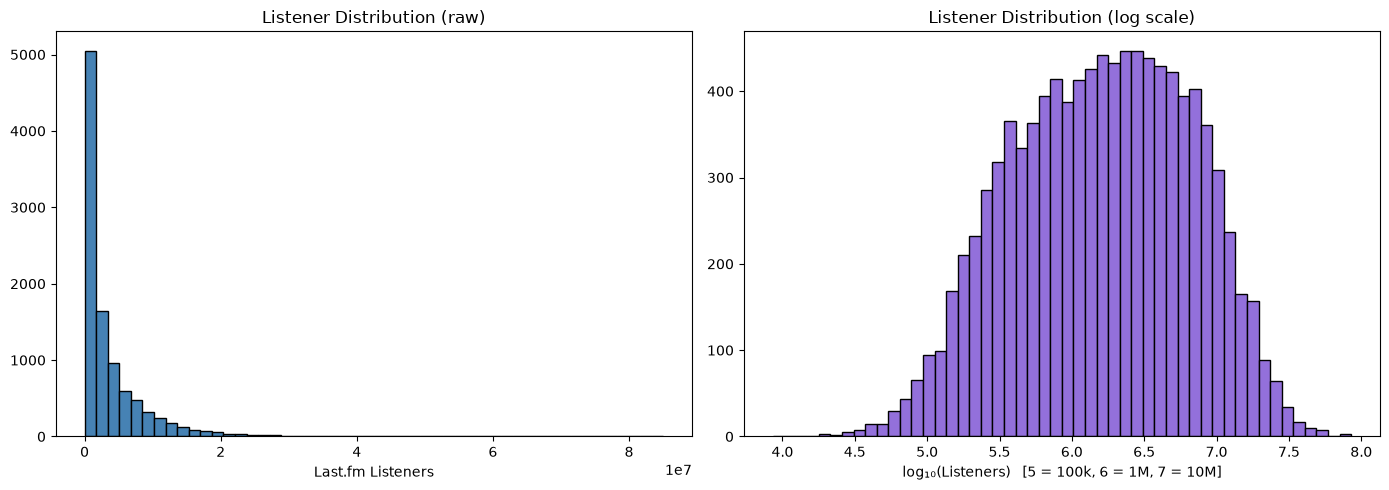

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['lastfm_listeners'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Listener Distribution (raw)')
axes[0].set_xlabel('Last.fm Listeners')

# Chart 2: log scale — much easier to read and interpret
df['log_listeners'] = np.log10(df['lastfm_listeners'])

axes[1].hist(df['log_listeners'], bins=50, color='mediumpurple', edgecolor='black')
axes[1].set_title('Listener Distribution (log scale)')
axes[1].set_xlabel('log₁₀(Listeners)   [5 = 100k, 6 = 1M, 7 = 10M]')

plt.tight_layout()
plt.show()


In [ ]:
pd.crosstab(
    index   = df['vocal_style'],
    columns = df['electronic_production'],
    values  = df['lastfm_listeners'],
    aggfunc = 'mean'
)

electronic_production,none,prominent,subtle
vocal_style,,,
clean_only,2.921304e+06,9.972188e+06,6.550558e+06
mixed,1.476870e+06,5.904691e+06,3.501979e+06
screaming_heavy,7.247942e+05,3.134759e+06,1.704159e+06


In [ ]:
df.groupby('vocal_style')['lastfm_listeners'].agg(
    Songs='count',
    Mean='mean',
    Median='median'
)


,Songs,Mean,Median
vocal_style,,,
clean_only,3093,7.092663e+06,4975428.0
mixed,3502,3.317059e+06,1905144.5
screaming_heavy,3405,1.256418e+06,577939.0


In [ ]:
breakdown_map = {'3+': 2, '1-2': 1, '0': 0}
vocal_map     = {'screaming_heavy': 2, 'mixed': 1, 'clean_only': 0}
electronic_map= {'none': 0, 'subtle': 1, 'prominent': 2}
complexity_map= {'high': 2, 'medium': 1, 'low': 0}

# Apply the maps — create new number columns
df['breakdown_num']   = df['breakdown_density'].map(breakdown_map)
df['vocal_num']       = df['vocal_style'].map(vocal_map)
df['electronic_num']  = df['electronic_production'].map(electronic_map)
df['complexity_num']  = df['guitar_complexity'].map(complexity_map)
df['tuning_num']      = (df['dropped_tuning'] == 'yes').astype(int)

print(df[['vocal_style', 'vocal_num']].head())
print(df[['dropped_tuning', 'tuning_num']].head(10))
      

       vocal_style  vocal_num
0  screaming_heavy          2
1       clean_only          0
2            mixed          1
3            mixed          1
4  screaming_heavy          2
  dropped_tuning  tuning_num
0            yes           1
1             no           0
2            yes           1
3             no           0
4            yes           1
5             no           0
6            yes           1
7             no           0
8             no           0
9             no           0


Text(0, 0.5, 'LastFM Listeners')

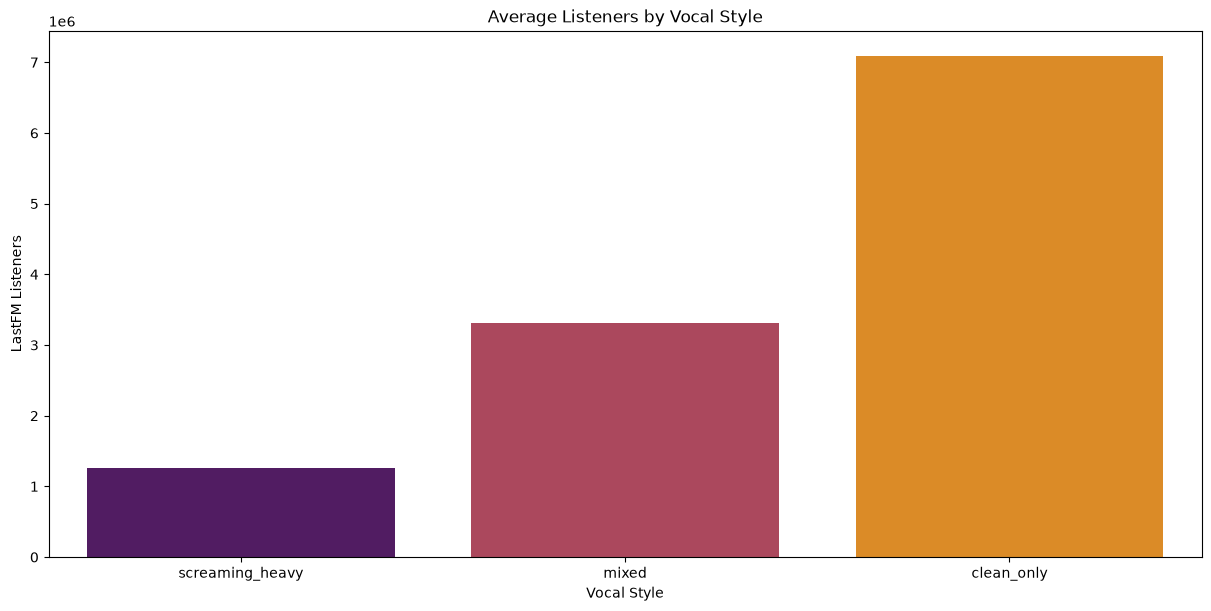

In [ ]:
plt.figure(figsize=(12,6), layout="constrained")
avg = df.groupby('vocal_style')['lastfm_listeners'].mean().sort_values()
voc_edmchart = sn.barplot(x = avg.index, y=avg.values, palette = 'inferno').set(title = 'Average Listeners by Vocal Style')
plt.xlabel("Vocal Style")
plt.ylabel("LastFM Listeners")



Text(0, 0.5, 'LastFM Listeners')

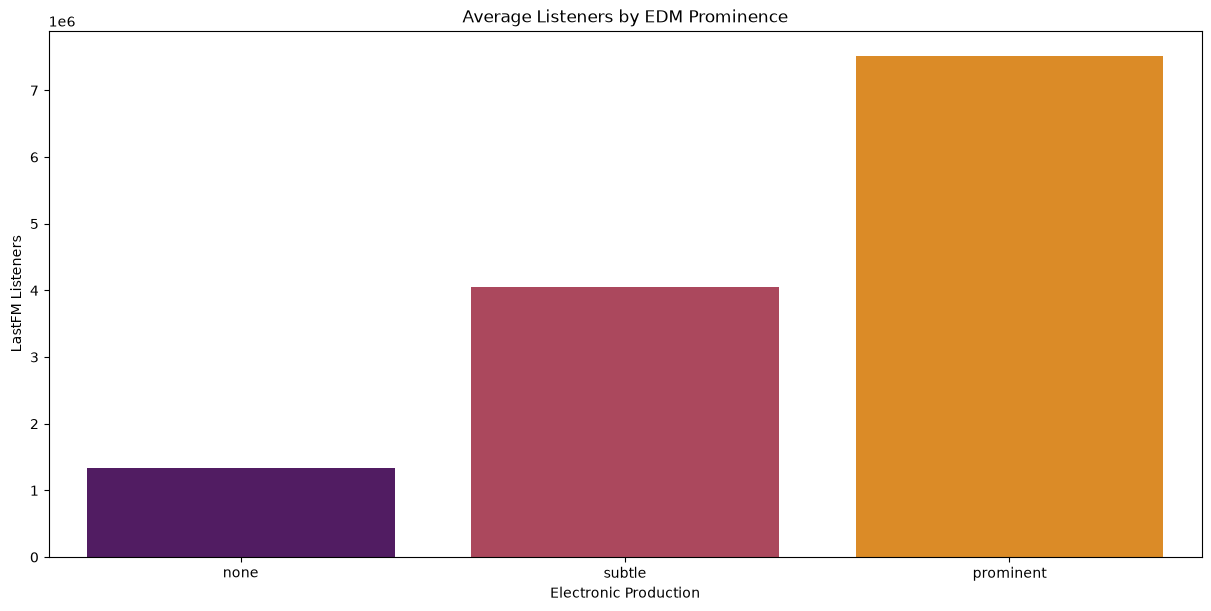

In [ ]:
plt.figure(figsize=(12,6), layout="constrained")
avg = df.groupby('electronic_production')['lastfm_listeners'].mean().sort_values()
voc_edmchart = sn.barplot(x = avg.index, y=avg.values, palette = 'inferno').set(title = 'Average Listeners by EDM Prominence')
plt.xlabel("Electronic Production")
plt.ylabel("LastFM Listeners")

Text(0.5, 1.0, 'Listeners vs Musical Factors')

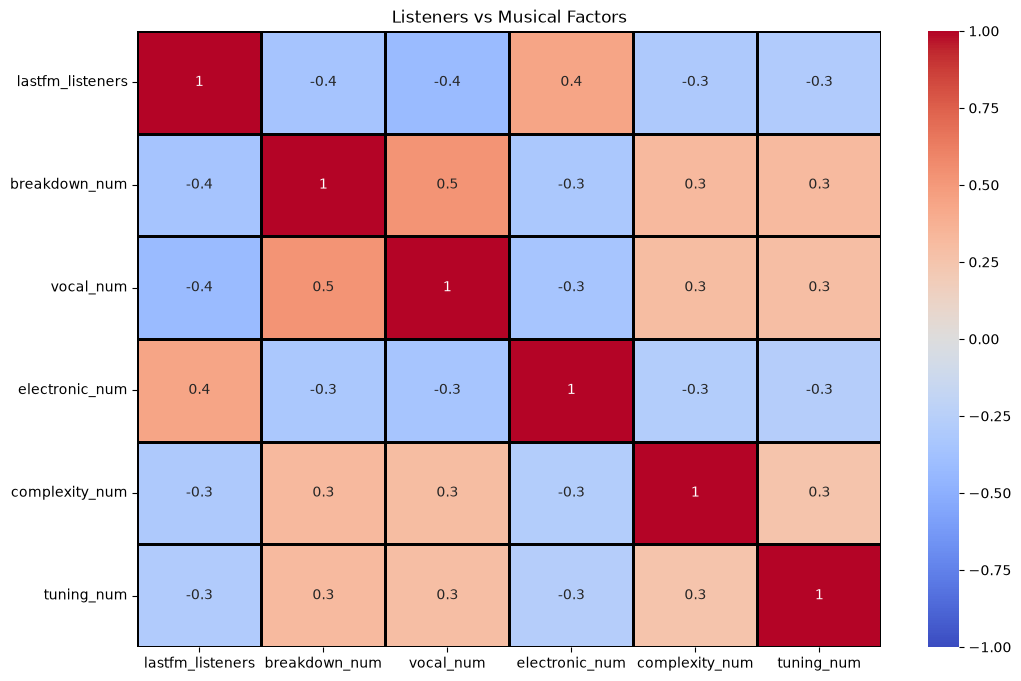

In [ ]:
corr_df = df.drop(["era", "album", "band", "song", "log_listeners"], axis=1).corr(method='pearson', numeric_only=True)
plt.figure(figsize=(12,8))
heatmap = sn.heatmap(corr_df, annot=True, fmt=".1g", vmin=-1, vmax=1, center=0, cmap="coolwarm", linewidths=1, linecolor='black')
heatmap.set_title("Listeners vs Musical Factors")

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Convert era to 0 (underground) or 1 (mainstream/crossover)
era_map = {'underground': 0, 'crossover': 1, 'mainstream': 1}
df['era_binary'] = df['era'].map(era_map)

# X = the musical features (inputs)
# y = the era label (what we're trying to predict)
X = df[['breakdown_num', 'vocal_num', 'electronic_num',
        'complexity_num', 'tuning_num']]
y = df['era_binary']

# Split: 80% to train the model, 20% to test it
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train the model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Test how accurate it is
y_pred = model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.1%}")

# Which features matter most?
feature_names = ['breakdown_density', 'vocal_style',
                 'electronic_production', 'guitar_complexity', 'dropped_tuning']

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': model.coef_[0]
}).sort_values('coefficient')

print(coef_df)

Accuracy: 84.2%
                 feature  coefficient
1            vocal_style    -1.212707
4         dropped_tuning    -1.212477
3      guitar_complexity    -0.827671
0      breakdown_density    -0.585478
2  electronic_production     1.465338


In [ ]:
# Initialize a local Git repository in your current project folder
!git init
!git remote remove origin
!git remote add origin https://github.com/Inc-pixel/metalcore-crossover-analysis.git
!git push -u origin main

# Stage your Jupyter Notebook file (or use !git add . to stage all files)
!git add Untitled.ipynb

# Commit the files with a descriptive message
!git commit -m "Initial commit of Jupyter Notebook"

# Rename your default branch to 'main'
!git branch -M main

# Link your local folder to your remote GitHub repository
!git remote add origin https://github.com/Inc-pixel/metalcore-crossover-analysis.git

# Push your project files up to the GitHub repository
!git push -u origin main

Reinitialized existing Git repository in C:/Windows/System32/.git/
